# MRMS Radar Data Pipeline

Fetch NOAA **MRMS** (Multi-Radar/Multi-Sensor) radar products for New York City.

**Source:** NOAA Open Data on AWS, `s3://noaa-mrms-pds` (anonymous HTTPS, archive from
Oct 2020), with the Iowa Environmental Mesonet mtarchive mirror as fallback.

## Key Features
- 0.01° (~1 km) CONUS grid, cropped to NYC on download — only the crop is stored
- Products: hourly QPE (gauge-corrected Pass 2 and radar-only), 2-min rate and precip type
- Per-product / per-day NetCDF cache: re-runs never re-download
- Confirmed archive gaps are remembered, never filled with 0

## Pipeline Steps
1. Configure products, window and domain
2. Fetch (fills the cache under `dataset/raw/radar/mrms/cache/`)
3. Inspect: event map, precip type, time series at the ASOS airports
4. Cache inventory
5. Optional: export the window to one NetCDF file

Same as the command line: `python src/fetch_data/main.py mrms --start … --end …`.
Requires `eccodes` (see `requirements.txt`).

## 1. Configuration

**Products** (name → subsampling; `None` = native cadence):
- `MultiSensor_QPE_01H_Pass2` — hourly gauge-corrected precipitation (mm), the reference
- `RadarOnly_QPE_01H` — hourly radar-only precipitation (mm), independent of gauges
- `PrecipRate` — instantaneous rate (mm/h), every 2 min
- `PrecipFlag` — surface precipitation type, every 2 min

**Window:** UTC. The default is the 2024-01-09/10 coastal storm.

In [1]:
import sys
import warnings
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path.cwd().parent.parent))       # src/
from fetch_data.mrms import (MRMSClient, NYC, PRECIP_FLAG, cache_inventory,
                             event_accumulation, sample_points)

# CONFIGURATION
PRODUCTS = {
    'MultiSensor_QPE_01H_Pass2': None,
    'RadarOnly_QPE_01H': None,
    'PrecipFlag': '10min',
    'PrecipRate': '10min',
}
START, END = '2024-01-09 12:00', '2024-01-10 12:00'
DOMAIN = NYC                                             # 40.48–40.93 N, 74.27–73.68 W
SAVE_NETCDF = False                                      # §5: export the window to one file

client = MRMSClient()
print('cache:', client.cache_dir)

cache: <repo>/dataset/raw/radar/mrms/cache


## 2. Fetch

`client.load()` returns `(time, lat, lon)` fields; missing archive times are listed in
`attrs['missing_times']`.

In [2]:
fields = {}
for product, freq in PRODUCTS.items():
    fields[product] = client.load(product, START, END, DOMAIN, freq=freq)
    da = fields[product]
    print(f"✓ {product:27s} {da.sizes['time']:4d} fields  {da.sizes['lat']}×{da.sizes['lon']} cells  "
          f"{len(da.attrs['missing_times'])} missing  [{da.attrs['units']}]")

✓ MultiSensor_QPE_01H_Pass2     25 fields  45×59 cells  0 missing  [mm]


✓ RadarOnly_QPE_01H             25 fields  45×59 cells  0 missing  [mm]


✓ PrecipFlag                   145 fields  45×59 cells  0 missing  [category]


✓ PrecipRate                   145 fields  45×59 cells  0 missing  [mm/h]


## 3. Inspect

**3a.** Storm total from hourly Pass 2 QPE vs. radar-only (same color scale).

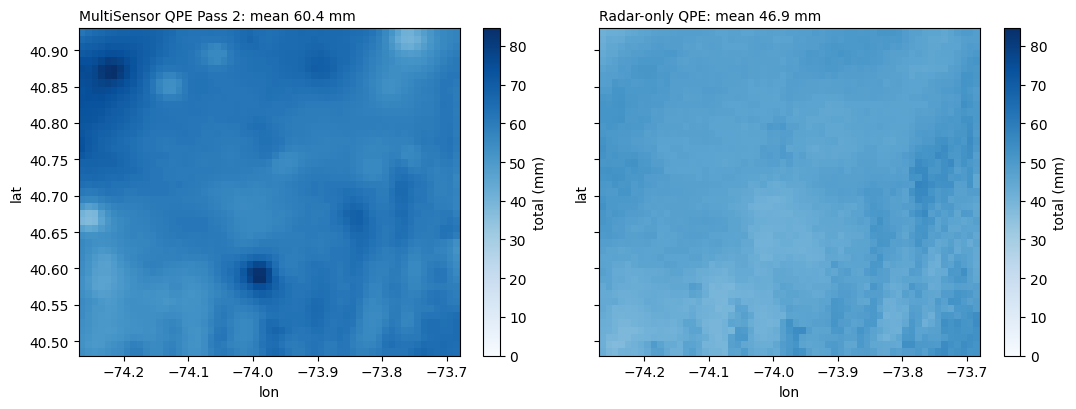

In [3]:
qpe = event_accumulation(START, END, DOMAIN, client=client)
ro = event_accumulation(START, END, DOMAIN, product='RadarOnly_QPE_01H', client=client)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
vmax = float(max(qpe.max(), ro.max()))
for ax, da, title in zip(axes, (qpe, ro), ('MultiSensor QPE Pass 2', 'Radar-only QPE')):
    da.plot(ax=ax, cmap='Blues', vmin=0, vmax=vmax, cbar_kwargs={'label': 'total (mm)'})
    ax.set_title(f'{title}: mean {float(da.mean()):.1f} mm', loc='left', fontsize=10)
fig.tight_layout()

**3b.** Surface precipitation type at the storm's wettest 10-min step. Codes:

{0: 'none', 1: 'warm stratiform rain', 3: 'snow', 6: 'convective rain', 7: 'rain mixed with hail', 10: 'cool stratiform rain', 91: 'tropical/stratiform rain mix', 96: 'tropical/convective rain mix'}


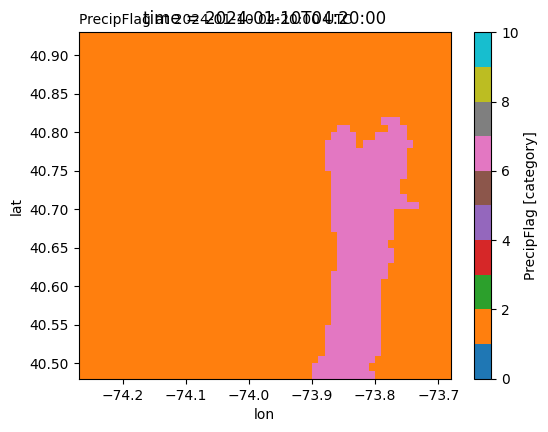

In [4]:
print(PRECIP_FLAG)
flag = fields['PrecipFlag']
t_peak = fields['PrecipRate'].mean(('lat', 'lon')).idxmax().values
flag.sel(time=t_peak).plot(figsize=(6, 4.5), cmap='tab10', vmin=0, vmax=10)
plt.title(f'PrecipFlag at {pd.Timestamp(t_peak)} UTC', loc='left', fontsize=10);

**3c.** Hourly QPE in the grid cell of each ASOS airport (mm per hour, hour-ending).

point,KJFK,KLGA,KNYC,KEWR,KTEB,KLDJ,KJRB
storm total (mm),62.0,58.0,62.299999,60.0,62.200001,50.299999,56.599998


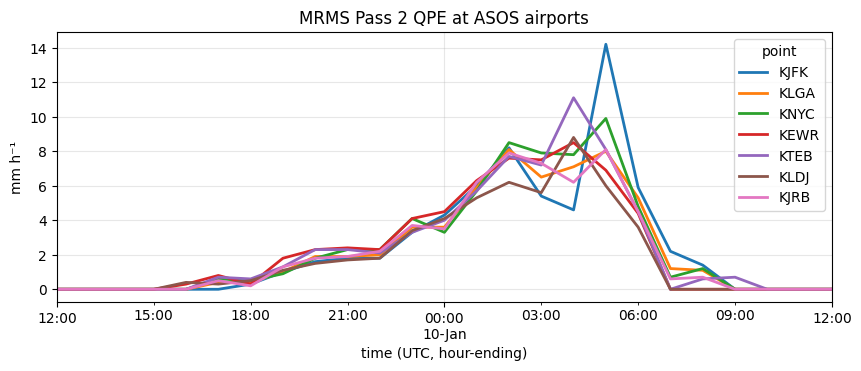

In [5]:
asos = pd.read_csv(Path.cwd().parent.parent.parent / 'dataset' / 'meta' / 'ASOS_stations.csv')
asos = asos[DOMAIN.contains(asos['Latitude'], asos['Longitude'])]
at_st = sample_points(fields['MultiSensor_QPE_01H_Pass2'], asos['Latitude'], asos['Longitude'],
                      names=asos['Station ID']).to_pandas()
ax = at_st.plot(figsize=(10, 3.5), lw=2)
ax.set(ylabel='mm h⁻¹', xlabel='time (UTC, hour-ending)', title='MRMS Pass 2 QPE at ASOS airports')
ax.grid(alpha=0.3)
at_st.sum().round(1).rename('storm total (mm)').to_frame().T

## 4. Cache inventory

Everything fetched so far, per product and domain (days = cached daily files).

In [6]:
cache_inventory()

,product,domain,days,first,last,size_mb
0,MultiSensor_QPE_01H_Pass1,nyc-05634d55,25,20201216,20260223,1.02
1,MultiSensor_QPE_01H_Pass2,impl2_overview-376c435d,9,20231121,20240111,1.79
2,MultiSensor_QPE_01H_Pass2,nyc-05634d55,594,20201207,20260314,12.25
3,MultiSensor_QPE_24H_Pass2,nyc-05634d55,20,20231030,20240129,0.37
4,PrecipFlag,nyc-05634d55,134,20201216,20260313,3.18
5,PrecipRate,nyc-05634d55,44,20231121,20260224,6.53
6,PrecipRate,openmesh-3e92b253,1,20240110,20240110,0.02
7,RadarOnly_QPE_01H,nyc-05634d55,70,20201216,20260224,2.33


## 5. Optional: export the window to one NetCDF

Writes `dataset/raw/radar/mrms/exports/mrms_nyc_{start}_{end}.nc` with one variable per
product (the 10-min products on their own time axis). Set `SAVE_NETCDF = True` in §1.

In [7]:
if SAVE_NETCDF:
    out = client.cache_dir.parent / 'exports' / f"mrms_nyc_{pd.Timestamp(START):%Y%m%dT%H}_{pd.Timestamp(END):%Y%m%dT%H}.nc"
    out.parent.mkdir(parents=True, exist_ok=True)
    import xarray as xr
    ds = xr.Dataset({p: da.rename(time=f'time_{p}').drop_attrs() for p, da in fields.items()})
    ds.attrs = {'source': 'NOAA/NSSL MRMS via noaa-mrms-pds', 'domain': str(DOMAIN),
                'start': START, 'end': END, 'created_by': 'src/fetch_data/mrms/mrms_pipeline.ipynb'}
    ds.to_netcdf(out)
    print('saved →', out)
else:
    print('SAVE_NETCDF is False — nothing written')

SAVE_NETCDF is False — nothing written
